In [1]:
# Importing necessary libraries for data preprocessing
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Importing necessary libraries for building and evaluating models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.losses import KLDivergence, MeanSquaredError

# Importing libabry for hyperparameter tuning using optuna
import optuna

# Importing necessary libraries for saving and loading models
import joblib 

In [2]:
df = pd.read_csv('KDDTrain+.txt', header=None)

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
# Converting into binary classification
df[41] = (df[41] != 'normal') * 1

In [5]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [6]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove(42)  # removing additional info column

In [7]:
# Define preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)])

In [8]:
# Applying ColumnTransformer
df_processed = preprocessor.fit_transform(df.drop(columns=[41, 42]))

In [9]:
df_processed = pd.DataFrame(df_processed)
df_processed

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121
0,0.000000,3.558064e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.003914,0.003914,0.0,0.0,0.0,0.0,1.00,0.00,0.00,0.588235,0.098039,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.000000,1.057999e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025440,0.001957,0.0,0.0,0.0,0.0,0.08,0.15,0.00,1.000000,0.003922,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.240705,0.011742,1.0,1.0,0.0,0.0,0.05,0.07,0.00,1.000000,0.101961,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,1.681203e-07,6.223962e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.009785,0.009785,0.2,0.2,0.0,0.0,1.00,0.00,0.00,0.117647,1.000000,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.000000,1.442067e-07,3.206260e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.058708,0.062622,0.0,0.0,0.0,0.0,1.00,0.00,0.09,1.000000,1.000000,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.360078,0.048924,1.0,1.0,0.0,0.0,0.14,0.06,0.00,1.000000,0.098039,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [10]:
# Extract target variable
y = df[41].values

In [11]:
# Check shape of preprocessed data
df_processed.shape, y.shape

((125973, 122), (125973,))

In [12]:
# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [13]:
# Define the dimensionality of the bottleneck for each autoencoder
bottleneck_dims = [64, 32, 16, 8]

In [14]:
# Store the models and their encoders
autoencoders = []
encoders = []

In [15]:
weight_decay = 0.001
learning_rate = 0.005

In [16]:
# Define the sparsity parameter and target sparsity
sparsity_target = 0.01
sparsity_weight = 0.1

mse_loss = MeanSquaredError()
kl_loss = KLDivergence()

def custom_loss(y_true, y_pred):
    # Calculate the MSE loss
    mse = mse_loss(y_true, y_pred)

    # Calculate the average activation of the bottleneck layer
    avg_activation = K.mean(y_pred, axis=0)

    # Calculate the KL Divergence for the sparsity constraint
    kl = K.sum(sparsity_target * K.log(sparsity_target / avg_activation) +
               (1 - sparsity_target) * K.log((1 - sparsity_target) / (1 - avg_activation)))

    # Combine the MSE and KL Divergence losses
    return mse + sparsity_weight * kl

In [17]:
def autoencoder_model(bottleneck_dims):
    autoencoder = Sequential([
        Dense(64, activation = 'relu', input_shape=(df_processed.shape[1],)),
        Dense(bottleneck_dims, activation = 'relu'),
        Dense(df_processed.shape[1], activation = 'sigmoid')
    ])
    
    return autoencoder

# Define and train the autoencoders
for i, bottleneck_dim in enumerate(bottleneck_dims):

    print(f"Training {i+1} autoencoder model")
    # Define the autoencoder
    autoencoder = autoencoder_model(bottleneck_dim)
    
    # Compile the autoencoder
    autoencoder.compile(optimizer = Adam(learning_rate = learning_rate, decay = weight_decay), loss = custom_loss)
    
    # Train the autoencoder
    history = autoencoder.fit(df_processed, df_processed, epochs = 10, batch_size = 256, verbose = 1)
    
    # Define the encoder
    encoder = Sequential(autoencoder.layers[:2])
    
    # Save the autoencoder and encoder
    autoencoders.append(autoencoder)
    encoders.append(encoder)
    
    # Update df_processed for the next autoencoder
    df_processed = encoder.predict(df_processed)
    print("\n")

Training 1 autoencoder model
Epoch 1/10
493/493 [==============================] - 3s 3ms/step - loss: 0.1849
Epoch 2/10
493/493 [==============================] - 1s 3ms/step - loss: 0.0612
Epoch 3/10
493/493 [==============================] - 1s 2ms/step - loss: 0.0607
Epoch 4/10
493/493 [==============================] - 1s 2ms/step - loss: 0.0598A: 0s -
Epoch 5/10
493/493 [==============================] - 1s 2ms/step - loss: 0.0588
Epoch 6/10
493/493 [==============================] - 1s 2ms/step - loss: 0.0585
Epoch 7/10
493/493 [==============================] - 1s 2ms/step - loss: 0.0584
Epoch 8/10
493/493 [==============================] - 1s 2ms/step - loss: 0.0582
Epoch 9/10
493/493 [==============================] - 1s 2ms/step - loss: 0.0580
Epoch 10/10
493/493 [==============================] - 1s 3ms/step - loss: 0.0579


Training 2 autoencoder model
Epoch 1/10
493/493 [==============================] - 1s 1ms/step - loss: 2.4204
Epoch 2/10
493/493 [=====================

In [18]:
df_processed = pd.DataFrame(df_processed)
df_processed

,0,1,2,3,4,5,6,7
0,0.0,0.0,0.0,79.236359,0.000000,16.538164,0.0,66.535515
1,0.0,0.0,0.0,24.560020,0.000000,71.242386,0.0,69.140465
2,0.0,0.0,0.0,112.945717,0.000000,70.384460,0.0,0.000000
3,0.0,0.0,0.0,13.229316,19.825104,0.710353,0.0,55.083515
4,0.0,0.0,0.0,14.367292,28.879398,0.000000,0.0,57.951214
...,...,...,...,...,...,...,...,...
125968,0.0,0.0,0.0,115.136124,0.000000,70.901215,0.0,0.000000
125969,0.0,0.0,0.0,30.187330,4.516725,60.350510,0.0,61.671589
125970,0.0,0.0,0.0,87.585625,0.000000,16.405107,0.0,79.478104
125971,0.0,0.0,0.0,100.349770,14.568856,42.429916,0.0,27.570587


In [19]:
# Now, df_processed is the output from the last encoder. We can use this to train our LGBM model.
X_train, X_test, y_train, y_test = train_test_split(df_processed, y, test_size=0.2, random_state=42)

***

In [20]:
# Implementing LGBMClassifier Using Optuna for hyperparamter tunning 
# Define the objective function for optuna 
# define hyperparameter values using trial object 

def objective(trial):
    
    # define the hyperparameter values to search 
    
    param = {
        "objective": "binary",        
        "metric": "binary_logloss",                 
        "boosting_type": trial.suggest_categorical("boosting_type", ["gbdt", "dart", "rf"]),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.5, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 2, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 100),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0)
    }
    
    # Intialze and train the Model 
    lgbm_optune = LGBMClassifier(**param)
    lgbm_optune.fit(X_train, y_train)
    
    
    # Predict the test dataset
    pred_optune = lgbm_optune.predict(X_test)
    
    # Calculate Accuracy of the model 
    accuracy = accuracy_score(y_test, pred_optune)
    return accuracy

In [21]:
# Create a study object for optimization process
study = optuna.create_study(direction="maximize")
%time study.optimize(objective, n_trials=100)

[I 2023-09-26 13:41:37,000] A new study created in memory with name: no-name-b6a16b11-edf5-44dc-b9b9-bbc2775c5fa6


[LightGBM] [Warning] min_data_in_leaf is set=73, min_child_samples=74 will be ignored. Current value: min_data_in_leaf=73
[LightGBM] [Warning] bagging_freq is set=7, subsample_freq=0 will be ignored. Current value: bagging_freq=7
[LightGBM] [Warning] min_data_in_leaf is set=73, min_child_samples=74 will be ignored. Current value: min_data_in_leaf=73
[LightGBM] [Warning] bagging_freq is set=7, subsample_freq=0 will be ignored. Current value: bagging_freq=7
[LightGBM] [Info] Number of positive: 46857, number of negative: 53921
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.464953 -> initscore=-0.140420
[LightGBM] [Info] Start training from score -0.140420
[LightGBM] [Warning] No further splits with

[I 2023-09-26 13:41:42,292] Trial 0 finished with value: 0.981782099622941 and parameters: {'boosting_type': 'dart', 'learning_rate': 0.020802422706752144, 'num_leaves': 823, 'max_depth': 12, 'subsample': 0.5384651528910906, 'bagging_freq': 7, 'min_data_in_leaf': 73, 'min_child_samples': 74, 'colsample_bytree': 0.7537790104508051}. Best is trial 0 with value: 0.981782099622941.


[LightGBM] [Warning] min_data_in_leaf is set=73, min_child_samples=74 will be ignored. Current value: min_data_in_leaf=73
[LightGBM] [Warning] bagging_freq is set=7, subsample_freq=0 will be ignored. Current value: bagging_freq=7
[LightGBM] [Warning] min_data_in_leaf is set=96, min_child_samples=8 will be ignored. Current value: min_data_in_leaf=96
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] min_data_in_leaf is set=96, min_child_samples=8 will be ignored. Current value: min_data_in_leaf=96
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Info] Number of positive: 46857, number of negative: 53921
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003021 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] min_data_in_leaf is set=96, min_child_samples=8 will be ignored. Current value: min_data_in_leaf=96
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6


...

[LightGBM] [Warning] min_data_in_leaf is set=84, min_child_samples=89 will be ignored. Current value: min_data_in_leaf=84
[LightGBM] [Warning] bagging_freq is set=8, subsample_freq=0 will be ignored. Current value: bagging_freq=8
[LightGBM] [Warning] min_data_in_leaf is set=84, min_child_samples=89 will be ignored. Current value: min_data_in_leaf=84
[LightGBM] [Warning] bagging_freq is set=8, subsample_freq=0 will be ignored. Current value: bagging_freq=8
[LightGBM] [Info] Number of positive: 46857, number of negative: 53921
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.464953 -> initscore=-0.140420
[LightGBM] [Info] Start training from score -0.140420
[LightGBM] [Warning] No further splits with

[I 2023-09-26 13:44:41,979] Trial 98 finished with value: 0.9897995634054376 and parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.14706658043429044, 'num_leaves': 370, 'max_depth': 15, 'subsample': 0.9350373391613735, 'bagging_freq': 8, 'min_data_in_leaf': 84, 'min_child_samples': 89, 'colsample_bytree': 0.891328571860655}. Best is trial 86 with value: 0.990434610041675.


[LightGBM] [Warning] min_data_in_leaf is set=84, min_child_samples=89 will be ignored. Current value: min_data_in_leaf=84
[LightGBM] [Warning] bagging_freq is set=8, subsample_freq=0 will be ignored. Current value: bagging_freq=8
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=91 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=7, subsample_freq=0 will be ignored. Current value: bagging_freq=7
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=91 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=7, subsample_freq=0 will be ignored. Current value: bagging_freq=7
[LightGBM] [Info] Number of positive: 46857, number of negative: 53921
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002283 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data poi

[I 2023-09-26 13:44:43,851] Trial 99 finished with value: 0.9892438975987299 and parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.20475121040045202, 'num_leaves': 356, 'max_depth': 16, 'subsample': 0.9187069552173976, 'bagging_freq': 7, 'min_data_in_leaf': 100, 'min_child_samples': 91, 'colsample_bytree': 0.870261502766501}. Best is trial 86 with value: 0.990434610041675.


Wall time: 3min 6s


In [22]:
# Create the LGBMClassifier Using the best parameters
lgbm = LGBMClassifier(**study.best_params)
%time lgbm.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=86, min_child_samples=90 will be ignored. Current value: min_data_in_leaf=86
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] min_data_in_leaf is set=86, min_child_samples=90 will be ignored. Current value: min_data_in_leaf=86
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Info] Number of positive: 46857, number of negative: 53921
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002251 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.464953 -> initscore=-0.140420
[LightGBM] [Info] Start training from score -0.140420
[LightGBM] [Warning] No further splits with

LGBMClassifier(bagging_freq=6, colsample_bytree=0.9989568241508806,
               learning_rate=0.29572948506221924, max_depth=17,
               min_child_samples=90, min_data_in_leaf=86, num_leaves=389,
               subsample=0.8671080415283017)

In [23]:
# save the model to a file 
joblib.dump(lgbm, 'lgbm_optuna_binary_sparse_0.01.joblib')

['lgbm_optuna_binary_sparse_0.01.joblib']

In [24]:
# Predict the test dataset
%time y_pred_test = lgbm.predict(X_test)

# make the predictions
y_pred_test

[LightGBM] [Warning] min_data_in_leaf is set=86, min_child_samples=90 will be ignored. Current value: min_data_in_leaf=86
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
Wall time: 209 ms


array([0, 1, 1, ..., 0, 0, 1])

In [25]:
# Print the classification report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     13422
           1       0.99      0.99      0.99     11773

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195



In [26]:
#  Compute the AUC Score

lgbm_roc_score = roc_auc_score(y_test, y_pred_test)
lgbm_roc_score

0.9902708411386543

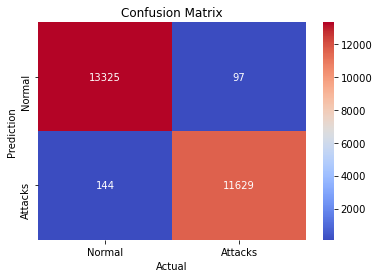

In [27]:
# Calculate Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Plot the confusion matrix
sns.heatmap(cm,
            annot = True, 
            fmt = "g", 
            cmap = 'coolwarm',
            yticklabels= ['Normal', 'Attacks'],
            xticklabels= ['Normal', 'Attacks'])

plt.title('Confusion Matrix')
plt.xlabel("Actual")
plt.ylabel("Prediction")
plt.show()

[LightGBM] [Warning] min_data_in_leaf is set=86, min_child_samples=90 will be ignored. Current value: min_data_in_leaf=86
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6


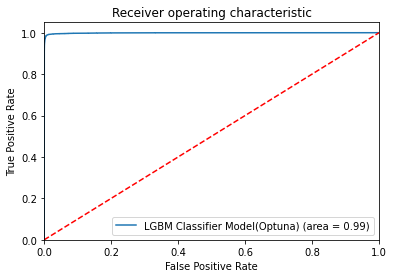

In [28]:
# Predict probabilities for the test data and Keep Probabilities of the positive class only
fpr, tpr, thresholds = roc_curve(y_test, lgbm.predict_proba(X_test)[:, 1]) 

# Plot the roc curve 
plt.plot(fpr, tpr, label='LGBM Classifier Model(Optuna) (area = %0.2f)' % lgbm_roc_score)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()   

****

In [29]:
# Predict the training time on train dataset
%time y_pred_train = lgbm.predict(X_train)

# printing the predictions
y_pred_train

[LightGBM] [Warning] min_data_in_leaf is set=86, min_child_samples=90 will be ignored. Current value: min_data_in_leaf=86
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
Wall time: 855 ms


array([0, 1, 1, ..., 1, 0, 0])

In [30]:
# Print the classification report for training dataset 
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     53921
           1       1.00      1.00      1.00     46857

    accuracy                           1.00    100778
   macro avg       1.00      1.00      1.00    100778
weighted avg       1.00      1.00      1.00    100778



In [31]:
def metrics(y_train, y_pred_train, y_test, y_pred_test):
    precision_train = precision_score(y_train, y_pred_train)
    precision_test = precision_score(y_test, y_pred_test)
    recall_train = recall_score(y_train, y_pred_train)
    recall_test = recall_score(y_test, y_pred_test)
    f1score_train = f1_score(y_train, y_pred_train)
    f1score_test = f1_score(y_test, y_pred_test)
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    metrics_dict = {
        "Precision (Train)": precision_train,
        "Precision (Test)": precision_test,
        "Recall (Train)": recall_train,
        "Recall (Test)": recall_test,
        "F1 Score (Train)": f1score_train,
        "F1 Score (Test)": f1score_test,
        "Accuracy (Train)": accuracy_train,
        "Accuracy (Test)": accuracy_test,
    }
    
    return metrics_dict


metrics(y_train, y_pred_train, y_test, y_pred_test)

{'Precision (Train)': 0.9978012594727292,
 'Precision (Test)': 0.9917277844107112,
 'Recall (Train)': 0.997545724224769,
 'Recall (Test)': 0.9877686231206999,
 'F1 Score (Train)': 0.9976734754861156,
 'F1 Score (Test)': 0.9897442444359335,
 'Accuracy (Train)': 0.9978368294667487,
 'Accuracy (Test)': 0.990434610041675}

****

In [32]:
# Checking for overfitting

%time print('Training set score: {:.4f}'.format(lgbm.score(X_train, y_train)))

%time print('Test set score: {:.4f}'.format(lgbm.score(X_test, y_test)))

[LightGBM] [Warning] min_data_in_leaf is set=86, min_child_samples=90 will be ignored. Current value: min_data_in_leaf=86
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
Training set score: 0.9978
Wall time: 869 ms
[LightGBM] [Warning] min_data_in_leaf is set=86, min_child_samples=90 will be ignored. Current value: min_data_in_leaf=86
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
Test set score: 0.9904
Wall time: 233 ms


***

In [63]:
# False Alarm Rate

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# calculate false positive and True negative values 
FP = cm[0, 1]  
TN = cm[0, 0]  
TP = cm[1, 1]
FN = cm[1, 0]

False_alarm_rate = FP / (FP + TN)
Detection_rate = TP / (TP + FN)
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print(False_alarm_rate * 100)
print(Detection_rate * 100)

0.7226940843391447
98.77686231207


In [60]:
cm[0, 0]

13325

In [34]:
# Class distribution in Training dataset

class_distribution_train = pd.Series(y_train).value_counts()
print(class_distribution_train)

0    53921
1    46857
dtype: int64


In [35]:
# Class distribution in Testing dataset

class_distribution_test = pd.Series(y_test).value_counts()
print(class_distribution_test)

0    13422
1    11773
dtype: int64


***